# Notebook 06 — Train, Tune, and Evaluate

This notebook trains and evaluates the first late-delivery classification model.

Goals:
- Establish a simple baseline
- Train an initial machine-learning model
- Tune model hyperparameters using the validation split only
- Select metrics appropriate for class imbalance
- Tune the classification threshold using validation only
- Evaluate the final selected model on the test set once
- Save the trained model and evaluation results

Primary metric:
**Average Precision (PR-AUC)**

The test set must remain untouched until the final evaluation section.

Artifacts:
`artifacts/06_model/`

In [1]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)


pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.width",
    220
)

print(
    "Imports loaded successfully."
)

Imports loaded successfully.


In [2]:
def find_project_root():

    current_path = Path.cwd().resolve()

    candidate_roots = [
        current_path,
        *current_path.parents,
    ]

    for candidate in candidate_roots:

        if (
            (candidate / "compose.yaml").exists()
            and
            (candidate / "requirements.txt").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the Olist-MLOps project root. "
        "Run Jupyter from inside the project directory."
    )


PROJECT_ROOT = find_project_root()


FEATURES_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "05_features"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "06_model"
)

CHARTS_DIR = (
    OUTPUT_DIR
    / "charts"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CHARTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# --------------------------------------------------
# Training / validation artifacts
# --------------------------------------------------

X_TRAIN_PATH = (
    FEATURES_DIR
    / "X_train.npz"
)

X_VALIDATION_PATH = (
    FEATURES_DIR
    / "X_validation.npz"
)

Y_TRAIN_PATH = (
    FEATURES_DIR
    / "y_train.npy"
)

Y_VALIDATION_PATH = (
    FEATURES_DIR
    / "y_validation.npy"
)


# --------------------------------------------------
# Test paths
#
# Paths are defined here, but test data is NOT
# loaded until the final evaluation section.
# --------------------------------------------------

X_TEST_PATH = (
    FEATURES_DIR
    / "X_test.npz"
)

Y_TEST_PATH = (
    FEATURES_DIR
    / "y_test.npy"
)

TEST_IDS_PATH = (
    FEATURES_DIR
    / "test_order_ids.csv"
)


assert X_TRAIN_PATH.exists(), (
    f"Training feature matrix not found: {X_TRAIN_PATH}"
)

assert X_VALIDATION_PATH.exists(), (
    f"Validation feature matrix not found: {X_VALIDATION_PATH}"
)

assert Y_TRAIN_PATH.exists(), (
    f"Training labels not found: {Y_TRAIN_PATH}"
)

assert Y_VALIDATION_PATH.exists(), (
    f"Validation labels not found: {Y_VALIDATION_PATH}"
)


print(
    "Project root:",
    PROJECT_ROOT
)

print(
    "Features directory:",
    FEATURES_DIR
)

print(
    "Output directory:",
    OUTPUT_DIR
)

print(
    "\nTraining and validation artifacts found."
)

Project root: G:\(01)04\Qafza_MLOps\Olist-MLOps
Features directory: G:\(01)04\Qafza_MLOps\Olist-MLOps\artifacts\05_features
Output directory: G:\(01)04\Qafza_MLOps\Olist-MLOps\artifacts\06_model

Training and validation artifacts found.


In [3]:
X_train = sparse.load_npz(
    X_TRAIN_PATH
)

X_validation = sparse.load_npz(
    X_VALIDATION_PATH
)

y_train = np.load(
    Y_TRAIN_PATH
)

y_validation = np.load(
    Y_VALIDATION_PATH
)


print(
    "Train matrix:",
    X_train.shape
)

print(
    "Validation matrix:",
    X_validation.shape
)

print(
    "Train labels:",
    y_train.shape
)

print(
    "Validation labels:",
    y_validation.shape
)

Train matrix: (67529, 159)
Validation matrix: (14470, 159)
Train labels: (67529,)
Validation labels: (14470,)


In [4]:
assert (
    X_train.shape[0]
    == len(y_train)
)

assert (
    X_validation.shape[0]
    == len(y_validation)
)

assert (
    X_train.shape[1]
    == X_validation.shape[1]
)

assert set(
    np.unique(y_train)
) == {0, 1}

assert set(
    np.unique(y_validation)
) == {0, 1}


for name, matrix in {
    "Train":
        X_train,

    "Validation":
        X_validation,
}.items():

    values = (
        matrix.data
        if sparse.issparse(matrix)
        else matrix.ravel()
    )

    assert not np.isnan(values).any()
    assert not np.isinf(values).any()


print(
    "Train and validation validation passed."
)

Train and validation validation passed.


In [5]:
def class_summary(y):

    values, counts = np.unique(
        y,
        return_counts=True
    )

    result = pd.DataFrame({
        "class":
            values,

        "count":
            counts,
    })

    result[
        "percentage"
    ] = (
        result["count"]
        / len(y)
        * 100
    )

    return result


print(
    "Training distribution:"
)

display(
    class_summary(
        y_train
    )
)


print(
    "\nValidation distribution:"
)

display(
    class_summary(
        y_validation
    )
)

Training distribution:


,class,count,percentage
0,0,62239,92.166329
1,1,5290,7.833671



Validation distribution:


,class,count,percentage
0,0,13846,95.68763
1,1,624,4.31237


## Evaluation Strategy

The target is imbalanced: late deliveries are the minority class.

Therefore, accuracy alone is not sufficient.

### Primary metric

**Average Precision (PR-AUC)**

Average Precision focuses on the model's ability to identify the positive minority class across decision thresholds.

### Secondary metrics

- ROC-AUC
- F1-score
- Precision
- Recall
- Balanced Accuracy
- Accuracy

Accuracy is reported for completeness, but it is not used as the main model-selection metric.

Hyperparameters and the classification threshold are selected using the validation split only.

In [6]:
def evaluate_probabilities(
    y_true,
    probabilities,
    threshold=0.5,
):

    predictions = (
        probabilities
        >= threshold
    ).astype(int)

    metrics = {
        "average_precision":
            average_precision_score(
                y_true,
                probabilities
            ),

        "roc_auc":
            roc_auc_score(
                y_true,
                probabilities
            ),

        "f1":
            f1_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "precision":
            precision_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "recall":
            recall_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                predictions
            ),

        "accuracy":
            accuracy_score(
                y_true,
                predictions
            ),

        "threshold":
            threshold,
    }

    return metrics

In [7]:
dummy_model = DummyClassifier(
    strategy="prior"
)

dummy_model.fit(
    X_train,
    y_train
)

dummy_validation_probabilities = (
    dummy_model
    .predict_proba(
        X_validation
    )[:, 1]
)

dummy_validation_metrics = (
    evaluate_probabilities(
        y_validation,
        dummy_validation_probabilities,
        threshold=0.5,
    )
)

dummy_validation_metrics[
    "model"
] = "DummyClassifier"


display(
    pd.DataFrame(
        [dummy_validation_metrics]
    )
)

,average_precision,roc_auc,f1,precision,recall,balanced_accuracy,accuracy,threshold,model
0,0.043124,0.5,0.0,0.0,0.0,0.5,0.956876,0.5,DummyClassifier


In [8]:
initial_model = LogisticRegression(
    C=1.0,
    class_weight=None,
    solver="liblinear",
    max_iter=2000,
    random_state=42,
)

initial_model.fit(
    X_train,
    y_train
)

initial_validation_probabilities = (
    initial_model
    .predict_proba(
        X_validation
    )[:, 1]
)

initial_validation_metrics = (
    evaluate_probabilities(
        y_validation,
        initial_validation_probabilities,
        threshold=0.5,
    )
)

initial_validation_metrics[
    "model"
] = "Initial Logistic Regression"


display(
    pd.DataFrame(
        [initial_validation_metrics]
    )
)

,average_precision,roc_auc,f1,precision,recall,balanced_accuracy,accuracy,threshold,model
0,0.110373,0.738266,0.0,0.0,0.0,0.499892,0.956669,0.5,Initial Logistic Regression


In [9]:
initial_comparison = pd.DataFrame([
    dummy_validation_metrics,
    initial_validation_metrics,
])

comparison_columns = [
    "model",
    "average_precision",
    "roc_auc",
    "f1",
    "precision",
    "recall",
    "balanced_accuracy",
    "accuracy",
    "threshold",
]

initial_comparison = (
    initial_comparison[
        comparison_columns
    ]
)

display(
    initial_comparison
)

,model,average_precision,roc_auc,f1,precision,recall,balanced_accuracy,accuracy,threshold
0,DummyClassifier,0.043124,0.500000,0.0,0.0,0.0,0.500000,0.956876,0.5
1,Initial Logistic Regression,0.110373,0.738266,0.0,0.0,0.0,0.499892,0.956669,0.5


In [10]:
C_VALUES = [
    0.01,
    0.1,
    1.0,
    10.0,
]

CLASS_WEIGHTS = [
    None,
    "balanced",
]


tuning_rows = []


for C_value in C_VALUES:

    for class_weight in CLASS_WEIGHTS:

        print(
            "Training:",
            f"C={C_value},",
            f"class_weight={class_weight}"
        )

        candidate_model = LogisticRegression(
            C=C_value,
            class_weight=class_weight,
            solver="liblinear",
            max_iter=2000,
            random_state=42,
        )

        candidate_model.fit(
            X_train,
            y_train
        )

        validation_probabilities = (
            candidate_model
            .predict_proba(
                X_validation
            )[:, 1]
        )

        metrics = (
            evaluate_probabilities(
                y_validation,
                validation_probabilities,
                threshold=0.5,
            )
        )

        tuning_rows.append({
            "C":
                C_value,

            "class_weight":
                (
                    class_weight
                    if class_weight is not None
                    else "None"
                ),

            **metrics,
        })


tuning_results = pd.DataFrame(
    tuning_rows
)

print(
    "\nTuning complete."
)

Training: C=0.01, class_weight=None
Training: C=0.01, class_weight=balanced
Training: C=0.1, class_weight=None
Training: C=0.1, class_weight=balanced
Training: C=1.0, class_weight=None
Training: C=1.0, class_weight=balanced
Training: C=10.0, class_weight=None
Training: C=10.0, class_weight=balanced

Tuning complete.


In [11]:
tuning_results = (
    tuning_results
    .sort_values(
        "average_precision",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    tuning_results
)

,C,class_weight,average_precision,roc_auc,f1,precision,recall,balanced_accuracy,accuracy,threshold
0,0.01,None,0.116389,0.753914,0.000000,0.000000,0.000000,0.499964,0.956807,0.5
1,10.00,balanced,0.113451,0.742367,0.201425,0.143147,0.339744,0.624046,0.883829,0.5
2,1.00,balanced,0.113443,0.742535,0.201048,0.143051,0.338141,0.623426,0.884105,0.5
3,0.10,balanced,0.113081,0.743637,0.197781,0.141477,0.328526,0.619340,0.885073,0.5
4,0.01,balanced,0.112917,0.747302,0.196078,0.138340,0.336538,0.621035,0.880995,0.5
5,0.10,None,0.111391,0.742401,0.000000,0.000000,0.000000,0.499892,0.956669,0.5
6,1.00,None,0.110373,0.738266,0.000000,0.000000,0.000000,0.499892,0.956669,0.5
7,10.00,None,0.110156,0.737339,0.000000,0.000000,0.000000,0.499892,0.956669,0.5


In [12]:
best_row = (
    tuning_results
    .iloc[0]
)

BEST_C = float(
    best_row[
        "C"
    ]
)

BEST_CLASS_WEIGHT = (
    None
    if (
        best_row[
            "class_weight"
        ]
        == "None"
    )
    else best_row[
        "class_weight"
    ]
)


print(
    "Best validation configuration:"
)

print(
    "C:",
    BEST_C
)

print(
    "class_weight:",
    BEST_CLASS_WEIGHT
)

print(
    "Validation Average Precision:",
    f"{best_row['average_precision']:.6f}"
)

Best validation configuration:
C: 0.01
class_weight: None
Validation Average Precision: 0.116389


In [13]:
final_model = LogisticRegression(
    C=BEST_C,
    class_weight=BEST_CLASS_WEIGHT,
    solver="liblinear",
    max_iter=2000,
    random_state=42,
)

final_model.fit(
    X_train,
    y_train
)


final_validation_probabilities = (
    final_model
    .predict_proba(
        X_validation
    )[:, 1]
)


print(
    "Best model fitted on training split."
)

Best model fitted on training split.


In [14]:
precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_validation,
        final_validation_probabilities
    )
)


threshold_precision = (
    precision_values[:-1]
)

threshold_recall = (
    recall_values[:-1]
)


threshold_f1 = (
    2
    * threshold_precision
    * threshold_recall
    /
    (
        threshold_precision
        + threshold_recall
        + 1e-12
    )
)


best_threshold_index = int(
    np.argmax(
        threshold_f1
    )
)


BEST_THRESHOLD = float(
    thresholds[
        best_threshold_index
    ]
)


print(
    "Best threshold:",
    f"{BEST_THRESHOLD:.6f}"
)

print(
    "Validation F1 at best threshold:",
    f"{threshold_f1[best_threshold_index]:.6f}"
)

print(
    "Precision:",
    f"{threshold_precision[best_threshold_index]:.6f}"
)

print(
    "Recall:",
    f"{threshold_recall[best_threshold_index]:.6f}"
)

Best threshold: 0.082211
Validation F1 at best threshold: 0.209774
Precision: 0.139461
Recall: 0.423077


In [15]:
final_validation_metrics = (
    evaluate_probabilities(
        y_validation,
        final_validation_probabilities,
        threshold=BEST_THRESHOLD,
    )
)

final_validation_metrics[
    "model"
] = "Tuned Logistic Regression"


validation_comparison = pd.DataFrame([
    dummy_validation_metrics,
    initial_validation_metrics,
    final_validation_metrics,
])


validation_comparison = (
    validation_comparison[
        comparison_columns
    ]
)


display(
    validation_comparison
)

,model,average_precision,roc_auc,f1,precision,recall,balanced_accuracy,accuracy,threshold
0,DummyClassifier,0.043124,0.500000,0.000000,0.000000,0.000000,0.500000,0.956876,0.500000
1,Initial Logistic Regression,0.110373,0.738266,0.000000,0.000000,0.000000,0.499892,0.956669,0.500000
2,Tuned Logistic Regression,0.116389,0.753914,0.209774,0.139461,0.423077,0.652713,0.862543,0.082211


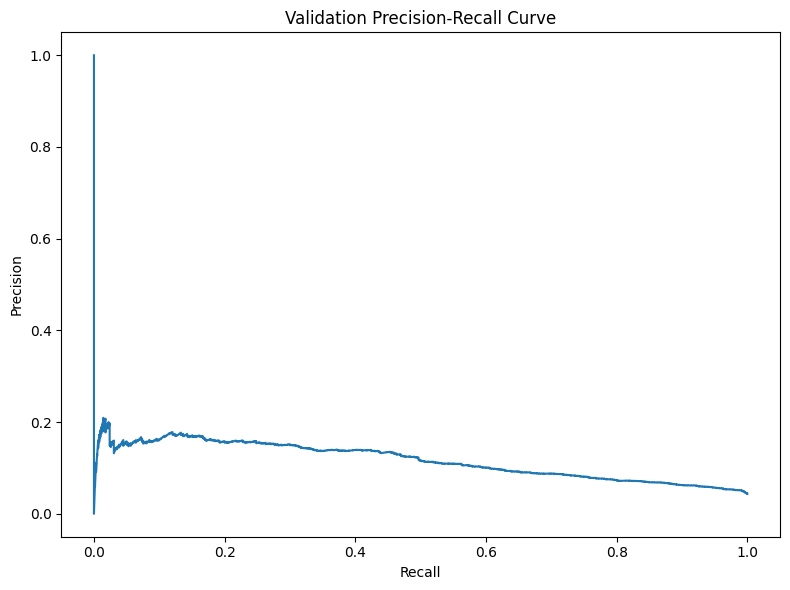

In [16]:
fig, ax = plt.subplots(
    figsize=(8, 6)
)

ax.plot(
    recall_values,
    precision_values
)

ax.set_title(
    "Validation Precision-Recall Curve"
)

ax.set_xlabel(
    "Recall"
)

ax.set_ylabel(
    "Precision"
)

plt.tight_layout()

plt.savefig(
    CHARTS_DIR
    / "validation_precision_recall_curve.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [17]:
tuning_results.to_csv(
    OUTPUT_DIR
    / "validation_tuning_results.csv",
    index=False
)

validation_comparison.to_csv(
    OUTPUT_DIR
    / "validation_model_comparison.csv",
    index=False
)

print(
    "Validation results saved."
)

Validation results saved.


# Final Test Evaluation

Everything above this point used only the training and validation splits.

The model configuration and classification threshold are now fixed.

From this point onward:

- No model hyperparameters will be changed.
- No feature decisions will be changed.
- The test set will be loaded once.
- Test results will be reported as the final unbiased evaluation.

The test result must not be used for additional tuning.

In [18]:
assert X_TEST_PATH.exists(), (
    f"Test feature matrix not found: {X_TEST_PATH}"
)

assert Y_TEST_PATH.exists(), (
    f"Test labels not found: {Y_TEST_PATH}"
)

assert TEST_IDS_PATH.exists(), (
    f"Test order IDs not found: {TEST_IDS_PATH}"
)


X_test = sparse.load_npz(
    X_TEST_PATH
)

y_test = np.load(
    Y_TEST_PATH
)

test_order_ids = pd.read_csv(
    TEST_IDS_PATH
)


print(
    "Test set opened for FINAL evaluation."
)

print(
    "X_test:",
    X_test.shape
)

print(
    "y_test:",
    y_test.shape
)

print(
    "Order IDs:",
    test_order_ids.shape
)

Test set opened for FINAL evaluation.
X_test: (14471, 159)
y_test: (14471,)
Order IDs: (14471, 1)


In [19]:
assert (
    X_test.shape[0]
    == len(y_test)
)

assert (
    X_test.shape[0]
    == len(test_order_ids)
)

assert (
    X_test.shape[1]
    == X_train.shape[1]
)

assert set(
    np.unique(y_test)
) == {0, 1}


test_values = (
    X_test.data
    if sparse.issparse(
        X_test
    )
    else X_test.ravel()
)


assert not np.isnan(
    test_values
).any()

assert not np.isinf(
    test_values
).any()


print(
    "Final test artifact validation passed."
)

Final test artifact validation passed.


In [20]:
test_probabilities = (
    final_model
    .predict_proba(
        X_test
    )[:, 1]
)


test_predictions = (
    test_probabilities
    >= BEST_THRESHOLD
).astype(int)


final_test_metrics = (
    evaluate_probabilities(
        y_test,
        test_probabilities,
        threshold=BEST_THRESHOLD,
    )
)


final_test_metrics[
    "model"
] = "Tuned Logistic Regression"


test_metrics_table = pd.DataFrame(
    [final_test_metrics]
)


display(
    test_metrics_table[
        comparison_columns
    ]
)

,model,average_precision,roc_auc,f1,precision,recall,balanced_accuracy,accuracy,threshold
0,Tuned Logistic Regression,0.076008,0.636449,0.106585,0.06444,0.308065,0.553931,0.77873,0.082211


In [21]:
test_confusion_matrix = (
    confusion_matrix(
        y_test,
        test_predictions
    )
)


tn, fp, fn, tp = (
    test_confusion_matrix
    .ravel()
)


confusion_table = pd.DataFrame(
    test_confusion_matrix,
    index=[
        "Actual On Time",
        "Actual Late",
    ],
    columns=[
        "Predicted On Time",
        "Predicted Late",
    ],
)


display(
    confusion_table
)


print(
    "True Negatives :",
    tn
)

print(
    "False Positives:",
    fp
)

print(
    "False Negatives:",
    fn
)

print(
    "True Positives :",
    tp
)

,Predicted On Time,Predicted Late
Actual On Time,11078,2773
Actual Late,429,191


True Negatives : 11078
False Positives: 2773
False Negatives: 429
True Positives : 191


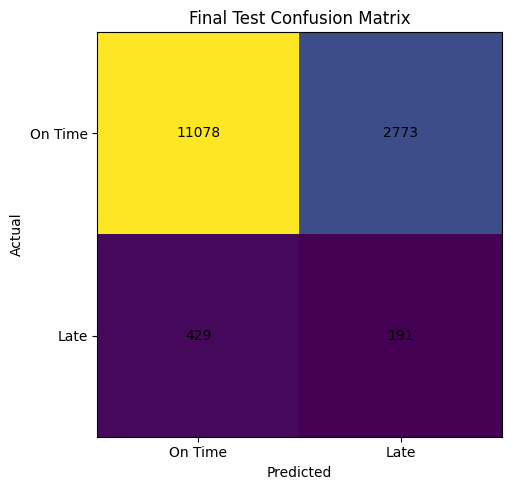

In [22]:
fig, ax = plt.subplots(
    figsize=(6, 5)
)

image = ax.imshow(
    test_confusion_matrix
)

ax.set_xticks(
    [0, 1]
)

ax.set_xticklabels([
    "On Time",
    "Late",
])

ax.set_yticks(
    [0, 1]
)

ax.set_yticklabels([
    "On Time",
    "Late",
])

ax.set_xlabel(
    "Predicted"
)

ax.set_ylabel(
    "Actual"
)

ax.set_title(
    "Final Test Confusion Matrix"
)


for i in range(2):

    for j in range(2):

        ax.text(
            j,
            i,
            str(
                test_confusion_matrix[
                    i,
                    j
                ]
            ),
            ha="center",
            va="center",
        )


plt.tight_layout()

plt.savefig(
    CHARTS_DIR
    / "test_confusion_matrix.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [23]:
test_predictions_output = (
    test_order_ids
    .copy()
)


test_predictions_output[
    "actual_is_late"
] = (
    y_test
)


test_predictions_output[
    "late_probability"
] = (
    test_probabilities
)


test_predictions_output[
    "predicted_is_late"
] = (
    test_predictions
)


test_predictions_output.to_csv(
    OUTPUT_DIR
    / "test_predictions.csv",
    index=False
)


print(
    "Test predictions saved."
)

Test predictions saved.


In [24]:
MODEL_BUNDLE_PATH = (
    OUTPUT_DIR
    / "model_bundle.joblib"
)


model_bundle = {
    "model":
        final_model,

    "classification_threshold":
        BEST_THRESHOLD,

    "model_type":
        "LogisticRegression",

    "best_C":
        BEST_C,

    "best_class_weight":
        BEST_CLASS_WEIGHT,

    "primary_metric":
        "average_precision",

    "feature_count":
        X_train.shape[1],
}


joblib.dump(
    model_bundle,
    MODEL_BUNDLE_PATH
)


print(
    "Final model bundle saved:"
)

print(
    MODEL_BUNDLE_PATH
)

Final model bundle saved:
G:\(01)04\Qafza_MLOps\Olist-MLOps\artifacts\06_model\model_bundle.joblib


In [25]:
RESULTS_JSON_PATH = (
    OUTPUT_DIR
    / "results_summary.json"
)


results_summary = {
    "baseline": {
        key:
            (
                float(value)
                if isinstance(
                    value,
                    (
                        np.floating,
                        float,
                        int,
                        np.integer,
                    )
                )
                else value
            )

        for key, value
        in dummy_validation_metrics.items()
    },

    "initial_model_validation": {
        key:
            (
                float(value)
                if isinstance(
                    value,
                    (
                        np.floating,
                        float,
                        int,
                        np.integer,
                    )
                )
                else value
            )

        for key, value
        in initial_validation_metrics.items()
    },

    "selected_model": {
        "model":
            "LogisticRegression",

        "C":
            BEST_C,

        "class_weight":
            BEST_CLASS_WEIGHT,

        "threshold":
            BEST_THRESHOLD,

        "selection_metric":
            "average_precision",
    },

    "final_validation": {
        key:
            (
                float(value)
                if isinstance(
                    value,
                    (
                        np.floating,
                        float,
                        int,
                        np.integer,
                    )
                )
                else value
            )

        for key, value
        in final_validation_metrics.items()
    },

    "final_test": {
        key:
            (
                float(value)
                if isinstance(
                    value,
                    (
                        np.floating,
                        float,
                        int,
                        np.integer,
                    )
                )
                else value
            )

        for key, value
        in final_test_metrics.items()
    },
}


RESULTS_JSON_PATH.write_text(
    json.dumps(
        results_summary,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8"
)


print(
    "Results JSON saved:"
)

print(
    RESULTS_JSON_PATH
)

Results JSON saved:
G:\(01)04\Qafza_MLOps\Olist-MLOps\artifacts\06_model\results_summary.json


In [26]:
RESULTS_MD_PATH = (
    OUTPUT_DIR
    / "results_summary.md"
)


summary_lines = [
    "# Notebook 06 — Model Results",
    "",
    "## Model",
    "",
    "- Model: Logistic Regression",
    f"- C: {BEST_C}",
    (
        "- Class weight: "
        f"{BEST_CLASS_WEIGHT}"
    ),
    (
        "- Classification threshold: "
        f"{BEST_THRESHOLD:.6f}"
    ),
    "",
    "## Selection Strategy",
    "",
    (
        "- Hyperparameters selected using "
        "the validation split only."
    ),
    (
        "- Primary model-selection metric: "
        "Average Precision (PR-AUC)."
    ),
    (
        "- Classification threshold selected "
        "using validation F1-score."
    ),
    (
        "- Test set opened only after model "
        "and threshold decisions were fixed."
    ),
    "",
    "## Baseline — Validation",
    "",
    (
        "- Average Precision: "
        f"{dummy_validation_metrics['average_precision']:.6f}"
    ),
    (
        "- F1: "
        f"{dummy_validation_metrics['f1']:.6f}"
    ),
    "",
    "## Final Model — Validation",
    "",
    (
        "- Average Precision: "
        f"{final_validation_metrics['average_precision']:.6f}"
    ),
    (
        "- ROC-AUC: "
        f"{final_validation_metrics['roc_auc']:.6f}"
    ),
    (
        "- F1: "
        f"{final_validation_metrics['f1']:.6f}"
    ),
    (
        "- Precision: "
        f"{final_validation_metrics['precision']:.6f}"
    ),
    (
        "- Recall: "
        f"{final_validation_metrics['recall']:.6f}"
    ),
    (
        "- Balanced Accuracy: "
        f"{final_validation_metrics['balanced_accuracy']:.6f}"
    ),
    "",
    "## Final Test Result",
    "",
    (
        "- Average Precision: "
        f"{final_test_metrics['average_precision']:.6f}"
    ),
    (
        "- ROC-AUC: "
        f"{final_test_metrics['roc_auc']:.6f}"
    ),
    (
        "- F1: "
        f"{final_test_metrics['f1']:.6f}"
    ),
    (
        "- Precision: "
        f"{final_test_metrics['precision']:.6f}"
    ),
    (
        "- Recall: "
        f"{final_test_metrics['recall']:.6f}"
    ),
    (
        "- Balanced Accuracy: "
        f"{final_test_metrics['balanced_accuracy']:.6f}"
    ),
    (
        "- Accuracy: "
        f"{final_test_metrics['accuracy']:.6f}"
    ),
    "",
    "## Test Confusion Matrix",
    "",
    f"- True negatives: {tn}",
    f"- False positives: {fp}",
    f"- False negatives: {fn}",
    f"- True positives: {tp}",
    "",
    "## Generalization Note",
    "",
    (
        "- Model performance decreased from validation "
        "to the later chronological test period."
    ),
    (
        "- Validation Average Precision: "
        f"{final_validation_metrics['average_precision']:.6f}"
    ),
    (
        "- Test Average Precision: "
        f"{final_test_metrics['average_precision']:.6f}"
    ),
    (
        "- Validation ROC-AUC: "
        f"{final_validation_metrics['roc_auc']:.6f}"
    ),
    (
        "- Test ROC-AUC: "
        f"{final_test_metrics['roc_auc']:.6f}"
    ),
    (
        "- This suggests temporal distribution shift "
        "or weaker generalization to later orders."
    ),
    (
        "- No additional tuning was performed using "
        "the test results."
    ),
]


RESULTS_MD_PATH.write_text(
    "\n".join(
        summary_lines
    ),
    encoding="utf-8"
)


print(
    "Human-readable summary saved:"
)

print(
    RESULTS_MD_PATH
)

Human-readable summary saved:
G:\(01)04\Qafza_MLOps\Olist-MLOps\artifacts\06_model\results_summary.md


In [27]:
test_metrics_table[
    comparison_columns
].to_csv(
    OUTPUT_DIR
    / "test_metrics.csv",
    index=False
)


confusion_table.to_csv(
    OUTPUT_DIR
    / "test_confusion_matrix.csv"
)


print(
    "Final test metric tables saved."
)

Final test metric tables saved.


In [28]:
loaded_bundle = joblib.load(
    MODEL_BUNDLE_PATH
)


loaded_model = (
    loaded_bundle[
        "model"
    ]
)

loaded_threshold = (
    loaded_bundle[
        "classification_threshold"
    ]
)


print(
    "Loaded model:",
    type(
        loaded_model
    ).__name__
)

print(
    "Loaded threshold:",
    loaded_threshold
)


assert (
    loaded_threshold
    == BEST_THRESHOLD
)

assert (
    loaded_bundle[
        "feature_count"
    ]
    == X_train.shape[1]
)


print(
    "\nSaved model artifact validated successfully."
)

Loaded model: LogisticRegression
Loaded threshold: 0.0822110764307922

Saved model artifact validated successfully.


In [29]:
print(
    "Notebook 06 artifacts:"
)

for path in sorted(
    OUTPUT_DIR.rglob("*")
):

    if path.is_file():

        print(
            "-",
            path.relative_to(
                OUTPUT_DIR
            )
        )

Notebook 06 artifacts:
- charts\test_confusion_matrix.png
- charts\validation_precision_recall_curve.png
- model_bundle.joblib
- results_summary.json
- results_summary.md
- test_confusion_matrix.csv
- test_metrics.csv
- test_predictions.csv
- validation_model_comparison.csv
- validation_tuning_results.csv


In [30]:
print(
    "=" * 72
)

print(
    "NOTEBOOK 06 COMPLETE"
)

print(
    "=" * 72
)

print(
    f"Model                  : "
    f"Logistic Regression"
)

print(
    f"Best C                 : "
    f"{BEST_C}"
)

print(
    f"Best class weight      : "
    f"{BEST_CLASS_WEIGHT}"
)

print(
    f"Classification threshold: "
    f"{BEST_THRESHOLD:.6f}"
)

print()

print(
    f"Baseline validation AP : "
    f"{dummy_validation_metrics['average_precision']:.6f}"
)

print(
    f"Final validation AP    : "
    f"{final_validation_metrics['average_precision']:.6f}"
)

print(
    f"Final test AP          : "
    f"{final_test_metrics['average_precision']:.6f}"
)

print(
    f"Final test ROC-AUC     : "
    f"{final_test_metrics['roc_auc']:.6f}"
)

print(
    f"Final test F1          : "
    f"{final_test_metrics['f1']:.6f}"
)

print(
    f"Final test Precision   : "
    f"{final_test_metrics['precision']:.6f}"
)

print(
    f"Final test Recall      : "
    f"{final_test_metrics['recall']:.6f}"
)

print()

print(
    "Model artifact        :",
    MODEL_BUNDLE_PATH
)

print(
    "Results summary       :",
    RESULTS_MD_PATH
)

print(
    "Test was used only for final evaluation."
)

NOTEBOOK 06 COMPLETE
Model                  : Logistic Regression
Best C                 : 0.01
Best class weight      : None
Classification threshold: 0.082211

Baseline validation AP : 0.043124
Final validation AP    : 0.116389
Final test AP          : 0.076008
Final test ROC-AUC     : 0.636449
Final test F1          : 0.106585
Final test Precision   : 0.064440
Final test Recall      : 0.308065

Model artifact        : G:\(01)04\Qafza_MLOps\Olist-MLOps\artifacts\06_model\model_bundle.joblib
Results summary       : G:\(01)04\Qafza_MLOps\Olist-MLOps\artifacts\06_model\results_summary.md
Test was used only for final evaluation.
